# 🌾 Agricultural Data — Python Analysis
**Dataset:** Agri_Data_Cleaned.csv | **Rows:** 4,178 | **Columns:** 51  
**Analysis includes:** Descriptive Statistics, Skewness, Kurtosis, Normality Tests, Multicollinearity (VIF), Correlation

In [1]:
# ─── 1. IMPORTS & SETUP ───────────────────────────────────────────────────────
import pandas as pd
import numpy as np
from scipy import stats
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', 60)
pd.set_option('display.float_format', '{:.4f}'.format)
plt.rcParams['figure.figsize'] = (12, 5)
sns.set_style('whitegrid')

print('✅ Libraries imported successfully')

✅ Libraries imported successfully


In [2]:
# ─── 2. LOAD DATA ─────────────────────────────────────────────────────────────
df = pd.read_csv('Agri_Data_Cleaned.csv', encoding='utf-8-sig')

print(f'Shape      : {df.shape}')
print(f'Rows       : {df.shape[0]:,}')
print(f'Columns    : {df.shape[1]}')
print(f'\nData Types:')
print(df.dtypes.value_counts())
print(f'\nMissing Values: {df.isnull().sum().sum()}')

Shape      : (4178, 51)
Rows       : 4,178
Columns    : 51

Data Types:
float64    34
str        10
int64       7
Name: count, dtype: int64

Missing Values: 0


In [3]:
# Preview first 5 rows
df.head()

,Area,District,Season,Avg Temp,Avg Humidity,Crop Name,Transplant,Growth,Harvest,Production,Max Temp,Min Temp,Max Relative Humidity,Min Relative Humidity,EVI,LAI,FPAR,Soil_Moisture_mm,NDVI_Season_Mean,NDVI_Season_Max,NDVI_Season_Min,NDVI_Season_Std,NDVI_Season_Range,NDVI_Season_CV,Avg_Salinity_Index,pH,Organic_Carbon,Nitrogen,Clay,Sand,Silt,Bulk_Density,CN_Ratio,pH_Suitability,Dominant_Soil_Texture,sm_surface,sm_rootzone,Rootzone_Surface_Diff,Moisture_Ratio,Water_Availability_Cat,Rainfall,Heat_Stress_Days,Wind_Mean,Wind_Max,Rain_Temp_Ratio,Extreme_Heat_Risk,Is_Extreme_Heat,LST_C,is_extreme_Heat_Stress_Days,is_extreme_Wind_Max,Yield
0,259,Bagerhat,Rabi,17.7500,55.0000,Wheat,December,Jan To March,April,200.0000,20,15.5000,65,50,0.3116,2.4184,0.6315,12.0780,0.5118,0.5712,0.4541,0.0511,0.1171,0.0999,560.4940,5.7300,33.0400,3.2150,28.2500,22.2300,49.5200,1.2300,8.7300,Optimal,Loamy,0.2675,0.3651,0.0976,1.4035,Optimal,220.4300,0.0000,1.4529,4.3300,11.2300,Low Risk,0,24.1445,0,0,0.7722
1,421,Bagerhat,Rabi,20.5000,60.0000,Maize 2,December,Jan To March,April,946.0000,27,14.0000,70,50,0.3116,2.4184,0.6315,12.0780,0.5118,0.5712,0.4541,0.0511,0.1171,0.0999,560.4940,5.7300,33.0400,3.2150,28.2500,22.2300,49.5200,1.2300,8.7300,Optimal,Loamy,0.2675,0.3651,0.0976,1.4035,Optimal,220.4300,0.0000,1.4529,4.3300,11.2300,Low Risk,0,24.1445,0,0,2.2470
2,145439,Bagerhat,Rabi,26.0000,72.5000,Boro,November,Dec To March,April,268754.0000,40,12.0000,85,60,0.3116,2.4184,0.6315,12.0780,0.5118,0.5712,0.4541,0.0511,0.1171,0.0999,560.4940,5.7300,33.0400,3.2150,28.2500,22.2300,49.5200,1.2300,8.7300,Optimal,Loamy,0.2935,0.3855,0.0920,1.3611,Optimal,220.4300,0.0000,1.4529,4.3300,11.2300,Low Risk,0,24.1445,0,0,1.8479
3,627,Bagerhat,Rabi,20.5000,80.0000,Sweet Potato,November,Dec To March,April,2200.0000,24,17.0000,90,70,0.3116,2.4184,0.6315,12.0780,0.5118,0.5712,0.4541,0.0511,0.1171,0.0999,560.4940,5.7300,33.0400,3.2150,28.2500,22.2300,49.5200,1.2300,8.7300,Optimal,Loamy,0.2935,0.3855,0.0920,1.3611,Optimal,220.4300,0.0000,1.4529,4.3300,11.2300,Low Risk,0,24.1445,0,0,3.5088
4,383,Bagerhat,Kharif 1,31.5000,70.0000,Mango,April,April To May,April To June,1913.0000,36,27.0000,90,50,0.3082,1.8113,0.4169,14.7710,0.2671,0.3077,0.2094,0.0420,0.0983,0.1570,883.0219,5.7300,33.0400,3.2150,28.2500,22.2300,49.5200,1.2300,8.7300,Optimal,Loamy,0.2769,0.3438,0.0669,1.3033,Optimal,656.3300,42.5000,2.4819,5.8600,22.7300,High Risk,1,28.4320,1,0,4.9948


In [4]:
# ─── 3. DESCRIPTIVE STATISTICS ────────────────────────────────────────────────
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(f'Numeric columns ({len(num_cols)}):', num_cols)

desc_stats = df[num_cols].describe().T
desc_stats['variance'] = df[num_cols].var()
desc_stats['skewness'] = df[num_cols].skew()
desc_stats['kurtosis'] = df[num_cols].kurtosis()
desc_stats['missing'] = df[num_cols].isnull().sum()
desc_stats = desc_stats.round(4)
desc_stats

Numeric columns (41): ['Area', 'Avg Temp', 'Avg Humidity', 'Production', 'Max Temp', 'Min Temp', 'Max Relative Humidity', 'Min Relative Humidity', 'EVI', 'LAI', 'FPAR', 'Soil_Moisture_mm', 'NDVI_Season_Mean', 'NDVI_Season_Max', 'NDVI_Season_Min', 'NDVI_Season_Std', 'NDVI_Season_Range', 'NDVI_Season_CV', 'Avg_Salinity_Index', 'pH', 'Organic_Carbon', 'Nitrogen', 'Clay', 'Sand', 'Silt', 'Bulk_Density', 'CN_Ratio', 'sm_surface', 'sm_rootzone', 'Rootzone_Surface_Diff', 'Moisture_Ratio', 'Rainfall', 'Heat_Stress_Days', 'Wind_Mean', 'Wind_Max', 'Rain_Temp_Ratio', 'Is_Extreme_Heat', 'LST_C', 'is_extreme_Heat_Stress_Days', 'is_extreme_Wind_Max', 'Yield']


,count,mean,std,min,25%,50%,75%,max,variance,skewness,kurtosis,missing
Area,4178.0000,8916.9557,44187.0963,1.0000,106.0000,335.5000,949.7500,663734.0000,1952499475.0397,7.9402,76.0660,0
Avg Temp,4178.0000,23.9608,4.6897,11.5000,20.0000,25.0000,27.5000,34.5000,21.9932,-0.1848,-0.4018,0
Avg Humidity,4178.0000,72.6140,9.1680,48.7500,67.5000,72.5000,80.0000,90.0000,84.0524,-0.6537,0.4227,0
Production,4178.0000,15841.2355,68746.0241,1.0000,233.0000,904.0000,3389.7500,1077242.0000,4726015825.7736,7.4907,69.3916,0
Max Temp,4178.0000,30.8679,5.8963,15.0000,27.0000,30.0000,35.0000,47.0000,34.7659,-0.0658,-0.0459,0
Min Temp,4178.0000,17.0537,5.4080,5.0000,14.0000,18.0000,20.0000,27.0000,29.2469,-0.1535,-0.6314,0
Max Relative Humidity,4178.0000,82.8897,8.5479,65.0000,80.0000,85.0000,90.0000,100.0000,73.0659,-0.5154,-0.5269,0
Min Relative Humidity,4178.0000,63.0175,10.1042,45.0000,60.0000,60.0000,70.0000,85.0000,102.0943,-0.0155,-0.6306,0
EVI,4178.0000,0.3444,0.0632,0.1869,0.3065,0.3321,0.3862,0.5059,0.0040,0.2424,0.1893,0
LAI,4178.0000,1.3722,0.4497,0.7101,1.0315,1.2896,1.5862,2.4184,0.2022,0.9411,0.1015,0


In [5]:
# ─── 4. SKEWNESS ANALYSIS ─────────────────────────────────────────────────────
skew_series = df[num_cols].skew().sort_values(ascending=False).round(4)
kurt_series = df[num_cols].kurtosis().sort_values(ascending=False).round(4)

skew_df = pd.DataFrame({
    'Skewness': skew_series,
    'Kurtosis': kurt_series
})

# Classify skewness
def classify_skew(s):
    if abs(s) < 0.5:  return 'Symmetric'
    elif abs(s) < 1.0: return 'Moderate Skew'
    else:              return 'High Skew ⚠️'

skew_df['Skew_Class'] = skew_df['Skewness'].apply(classify_skew)
skew_df['Direction']  = skew_df['Skewness'].apply(lambda x: 'Right (+)' if x > 0 else 'Left (−)')
print(skew_df.to_string())

                             Skewness  Kurtosis     Skew_Class  Direction
Area                           7.9402   76.0660   High Skew ⚠️  Right (+)
Avg Humidity                  -0.6537    0.4227  Moderate Skew   Left (−)
Avg Temp                      -0.1848   -0.4018      Symmetric   Left (−)
Avg_Salinity_Index             0.2020   -0.1201      Symmetric  Right (+)
Bulk_Density                  -0.4843   -0.0109      Symmetric   Left (−)
CN_Ratio                       0.1809    0.0164      Symmetric  Right (+)
Clay                           0.3168   -0.7951      Symmetric  Right (+)
EVI                            0.2424    0.1893      Symmetric  Right (+)
FPAR                           0.1483    0.2068      Symmetric  Right (+)
Heat_Stress_Days               1.1007   -0.5952   High Skew ⚠️  Right (+)
Is_Extreme_Heat                1.1902   -0.5838   High Skew ⚠️  Right (+)
LAI                            0.9411    0.1015  Moderate Skew  Right (+)
LST_C                         -0.4831 

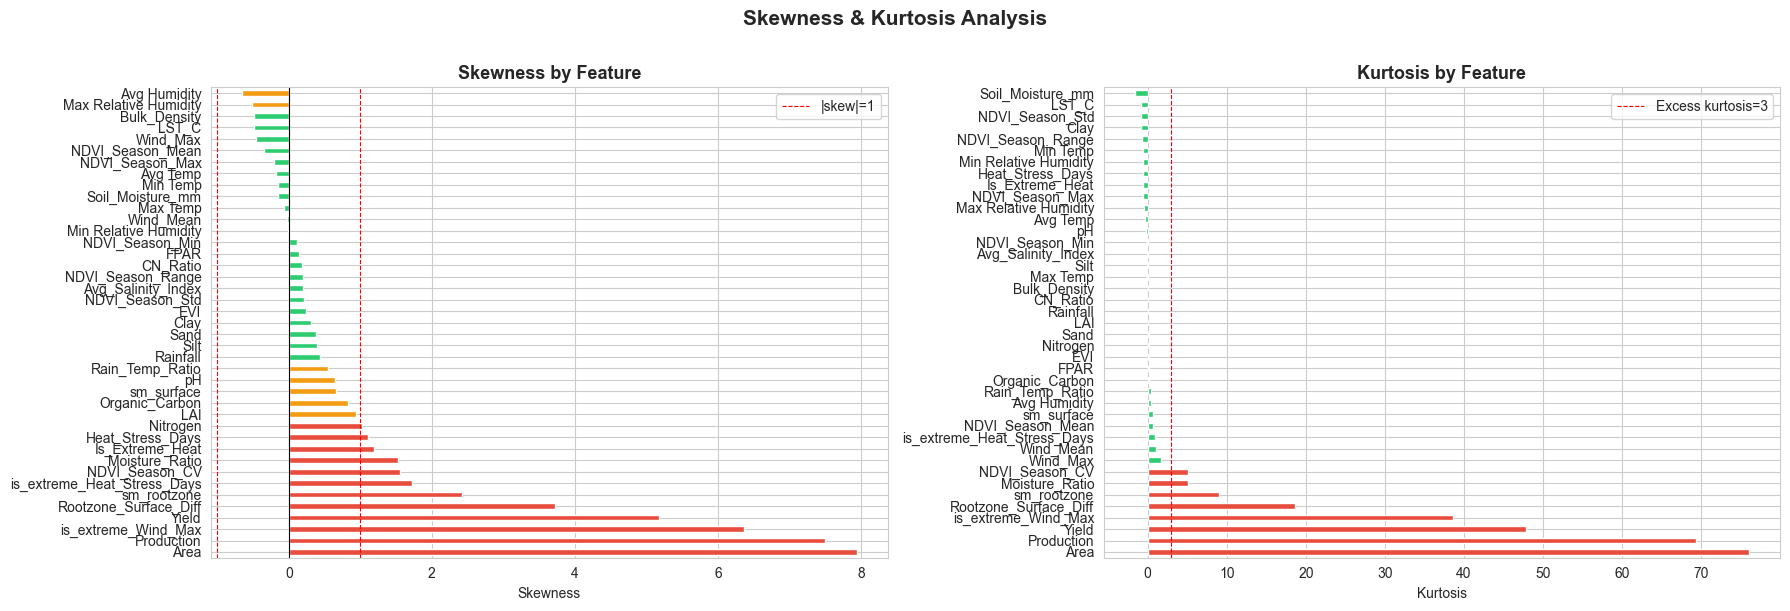

📊 Skewness chart saved


In [6]:
# Skewness bar chart
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

colors = ['#e74c3c' if abs(v) >= 1 else '#f39c12' if abs(v) >= 0.5 else '#2ecc71'
          for v in skew_series.values]
skew_series.plot(kind='barh', color=colors, ax=axes[0])
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].axvline(1, color='red', linewidth=0.8, linestyle='--', label='|skew|=1')
axes[0].axvline(-1, color='red', linewidth=0.8, linestyle='--')
axes[0].set_title('Skewness by Feature', fontweight='bold', fontsize=13)
axes[0].set_xlabel('Skewness')
axes[0].legend()

# Kurtosis
kurt_colors = ['#e74c3c' if abs(v) > 3 else '#2ecc71' for v in kurt_series.values]
kurt_series.plot(kind='barh', color=kurt_colors, ax=axes[1])
axes[1].axvline(3, color='red', linewidth=0.8, linestyle='--', label='Excess kurtosis=3')
axes[1].set_title('Kurtosis by Feature', fontweight='bold', fontsize=13)
axes[1].set_xlabel('Kurtosis')
axes[1].legend()

plt.suptitle('Skewness & Kurtosis Analysis', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('skew_kurt_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print('📊 Skewness chart saved')

Highly skewed variables (|skew| ≥ 1): ['Area', 'Production', 'is_extreme_Wind_Max', 'Yield', 'Rootzone_Surface_Diff', 'sm_rootzone']


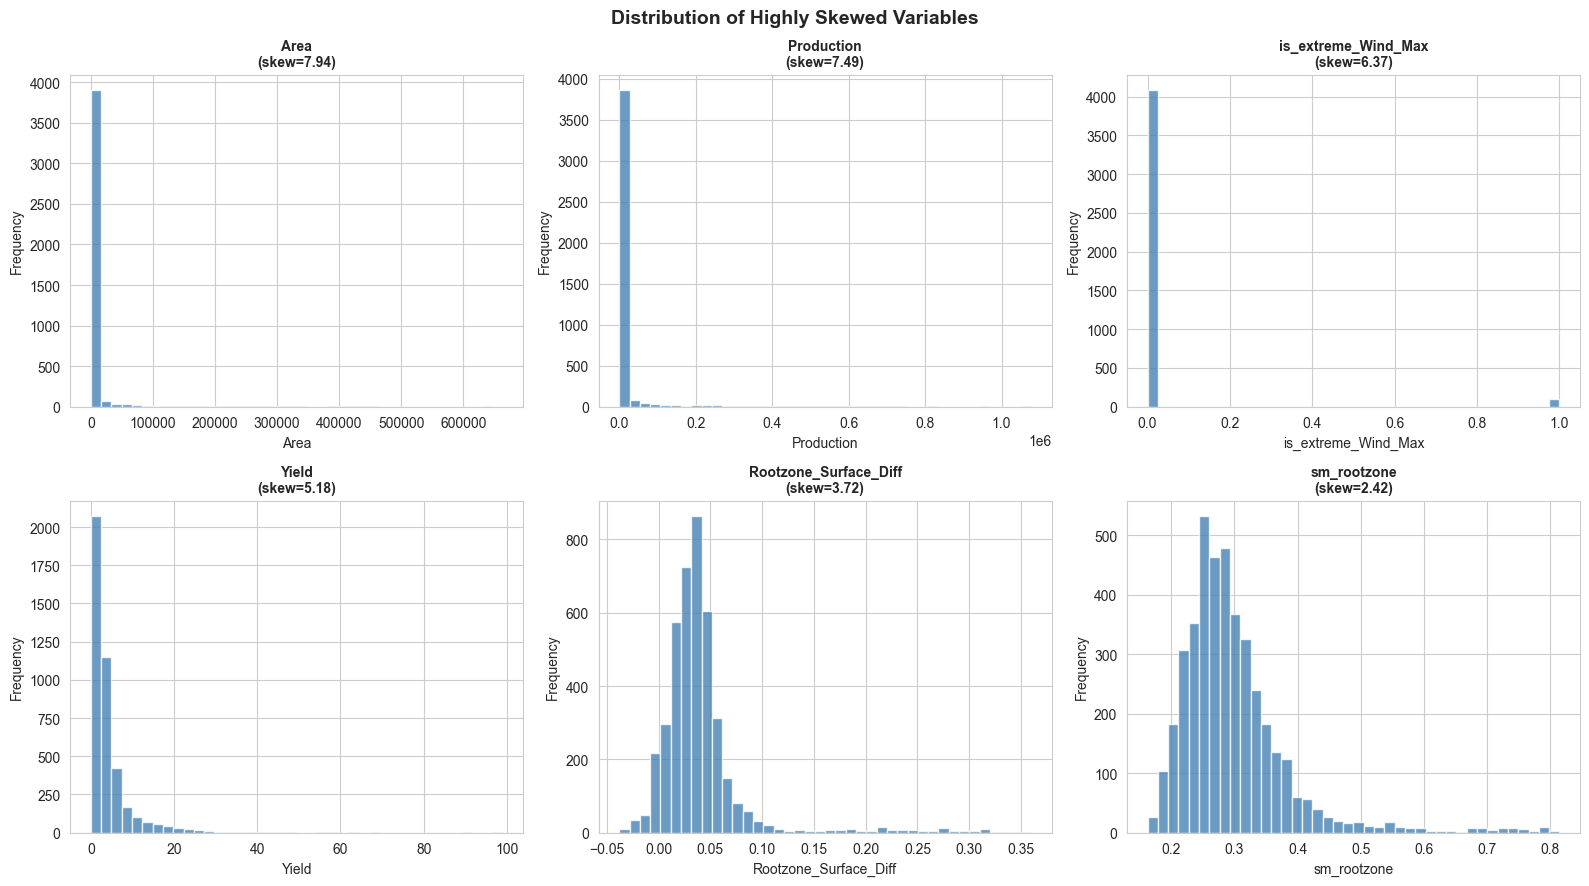

In [7]:
# Distribution plots for highly skewed variables
high_skew_cols = skew_series[abs(skew_series) >= 1].index.tolist()[:6]
print('Highly skewed variables (|skew| ≥ 1):', high_skew_cols)

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
for i, col in enumerate(high_skew_cols):
    axes[i].hist(df[col].dropna(), bins=40, color='steelblue', edgecolor='white', alpha=0.8)
    axes[i].set_title(f'{col}\n(skew={skew_series[col]:.2f})', fontsize=10, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')
plt.suptitle('Distribution of Highly Skewed Variables', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('high_skew_dist.png', dpi=150, bbox_inches='tight')
plt.show()

In [8]:
# ─── 5. NORMALITY TESTS (Shapiro-Wilk) ───────────────────────────────────────
print('=== Shapiro-Wilk Normality Test (sample n=500) ===')
print('H0: Data is normally distributed | p < 0.05 → Reject H0 (Non-normal)\n')

sample = df[num_cols].sample(min(500, len(df)), random_state=42)
normality_results = []
for col in num_cols:
    w, p = stats.shapiro(sample[col].dropna())
    normality_results.append({
        'Feature': col,
        'W_stat': round(w, 4),
        'p_value': round(p, 5),
        'Result': 'Non-normal ❌' if p < 0.05 else 'Normal ✅'
    })

norm_df = pd.DataFrame(normality_results)
print(norm_df.to_string(index=False))
print(f"\nSummary: {(norm_df['Result'].str.contains('Non')).sum()} non-normal, "
      f"{(~norm_df['Result'].str.contains('Non')).sum()} normal")

=== Shapiro-Wilk Normality Test (sample n=500) ===
H0: Data is normally distributed | p < 0.05 → Reject H0 (Non-normal)

                    Feature  W_stat  p_value       Result
                       Area  0.2045   0.0000 Non-normal ❌
                   Avg Temp  0.9746   0.0000 Non-normal ❌
               Avg Humidity  0.9543   0.0000 Non-normal ❌
                 Production  0.2385   0.0000 Non-normal ❌
                   Max Temp  0.9597   0.0000 Non-normal ❌
                   Min Temp  0.9530   0.0000 Non-normal ❌
      Max Relative Humidity  0.9251   0.0000 Non-normal ❌
      Min Relative Humidity  0.9449   0.0000 Non-normal ❌
                        EVI  0.9795   0.0000 Non-normal ❌
                        LAI  0.9089   0.0000 Non-normal ❌
                       FPAR  0.9916   0.0063 Non-normal ❌
           Soil_Moisture_mm  0.8246   0.0000 Non-normal ❌
           NDVI_Season_Mean  0.9789   0.0000 Non-normal ❌
            NDVI_Season_Max  0.9830   0.0000 Non-normal ❌
         

In [9]:
# ─── 6. MULTICOLLINEARITY — VARIANCE INFLATION FACTOR (VIF) ──────────────────
print('=== Variance Inflation Factor (VIF) ===')
print('VIF < 5   : Low multicollinearity ✅')
print('VIF 5–10  : Moderate multicollinearity ⚠️')
print('VIF > 10  : High multicollinearity 🔴')
print('VIF = ∞   : Perfect multicollinearity (linear dependence) 🚫\n')

def calc_vif(X):
    results = []
    cols = X.columns.tolist()
    for col in cols:
        y = X[col]
        x_other = X.drop(columns=[col])
        x_other = x_other.loc[:, x_other.std() > 0]
        reg = LinearRegression().fit(x_other, y)
        r2 = reg.score(x_other, y)
        vif = 1 / (1 - r2) if r2 < 0.9999 else np.inf
        results.append({'Feature': col, 'VIF': round(vif, 2)})
    return pd.DataFrame(results).sort_values('VIF', ascending=False)

X_num = df[num_cols].dropna()
X_num = X_num.loc[:, X_num.std() > 0]
vif_df = calc_vif(X_num)

def vif_class(v):
    if v == np.inf: return 'Perfect (∞) 🚫'
    elif v > 10:    return 'High 🔴'
    elif v > 5:     return 'Moderate ⚠️'
    else:           return 'Low ✅'

vif_df['Category'] = vif_df['VIF'].apply(vif_class)
print(vif_df.to_string(index=False))

=== Variance Inflation Factor (VIF) ===
VIF < 5   : Low multicollinearity ✅
VIF 5–10  : Moderate multicollinearity ⚠️
VIF > 10  : High multicollinearity 🔴
VIF = ∞   : Perfect multicollinearity (linear dependence) 🚫

                    Feature       VIF      Category
                   Avg Temp       inf Perfect (∞) 🚫
                   Min Temp       inf Perfect (∞) 🚫
                   Max Temp       inf Perfect (∞) 🚫
      Rootzone_Surface_Diff       inf Perfect (∞) 🚫
                 sm_surface       inf Perfect (∞) 🚫
                sm_rootzone       inf Perfect (∞) 🚫
                       Sand       inf Perfect (∞) 🚫
                       Clay       inf Perfect (∞) 🚫
                       Silt       inf Perfect (∞) 🚫
                   Rainfall 2391.1600        High 🔴
            Rain_Temp_Ratio 2329.0800        High 🔴
            NDVI_Season_Max  293.4700        High 🔴
          NDVI_Season_Range  237.2200        High 🔴
            NDVI_Season_Min  163.2600        High 🔴
    

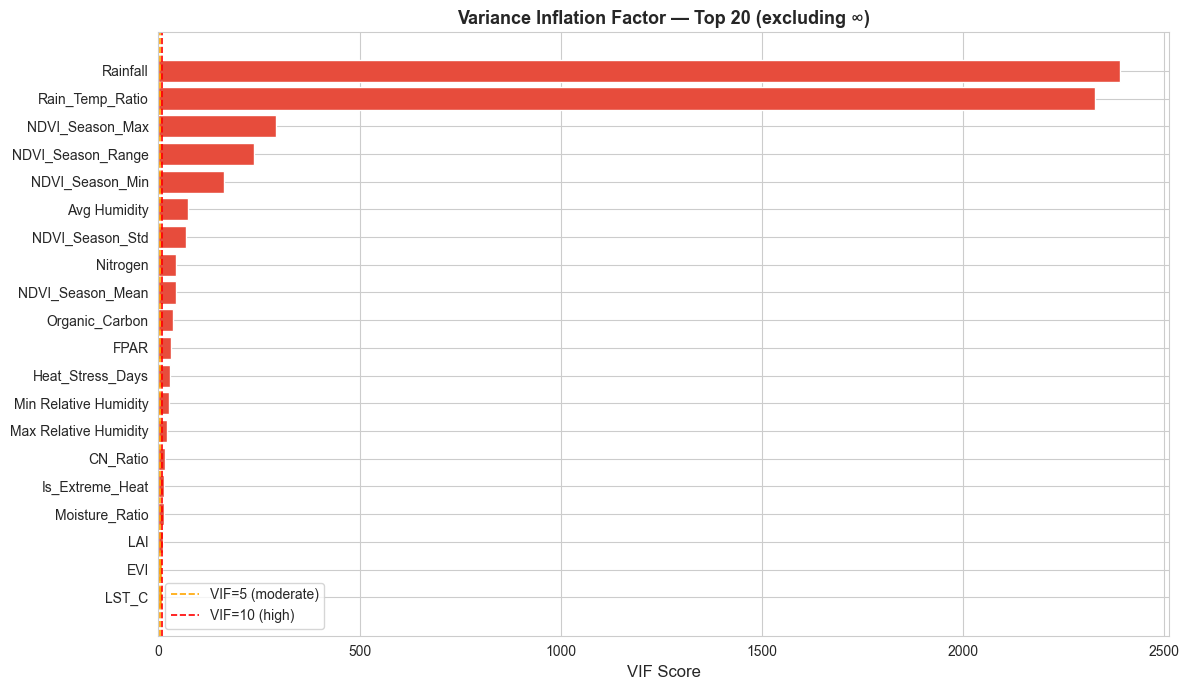


🚫 Perfect multicollinearity (VIF=∞): ['Avg Temp', 'Min Temp', 'Max Temp', 'Rootzone_Surface_Diff', 'sm_surface', 'sm_rootzone', 'Sand', 'Clay', 'Silt']
→ Likely: Clay+Sand+Silt sum to 100%; Avg Temp is linear combo of Max/Min Temp


In [10]:
# VIF visualization (finite values only)
vif_finite = vif_df[vif_df['VIF'] != np.inf].copy()
vif_finite_top = vif_finite.head(20)

colors = ['#e74c3c' if v > 10 else '#f39c12' if v > 5 else '#2ecc71'
          for v in vif_finite_top['VIF']]

plt.figure(figsize=(12, 7))
bars = plt.barh(vif_finite_top['Feature'], vif_finite_top['VIF'], color=colors)
plt.axvline(5, color='orange', linestyle='--', linewidth=1.2, label='VIF=5 (moderate)')
plt.axvline(10, color='red', linestyle='--', linewidth=1.2, label='VIF=10 (high)')
plt.xlabel('VIF Score', fontsize=12)
plt.title('Variance Inflation Factor — Top 20 (excluding ∞)', fontweight='bold', fontsize=13)
plt.legend()
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('vif_chart.png', dpi=150, bbox_inches='tight')
plt.show()

inf_cols = vif_df[vif_df['VIF'] == np.inf]['Feature'].tolist()
print(f'\n🚫 Perfect multicollinearity (VIF=∞): {inf_cols}')
print('→ Likely: Clay+Sand+Silt sum to 100%; Avg Temp is linear combo of Max/Min Temp')

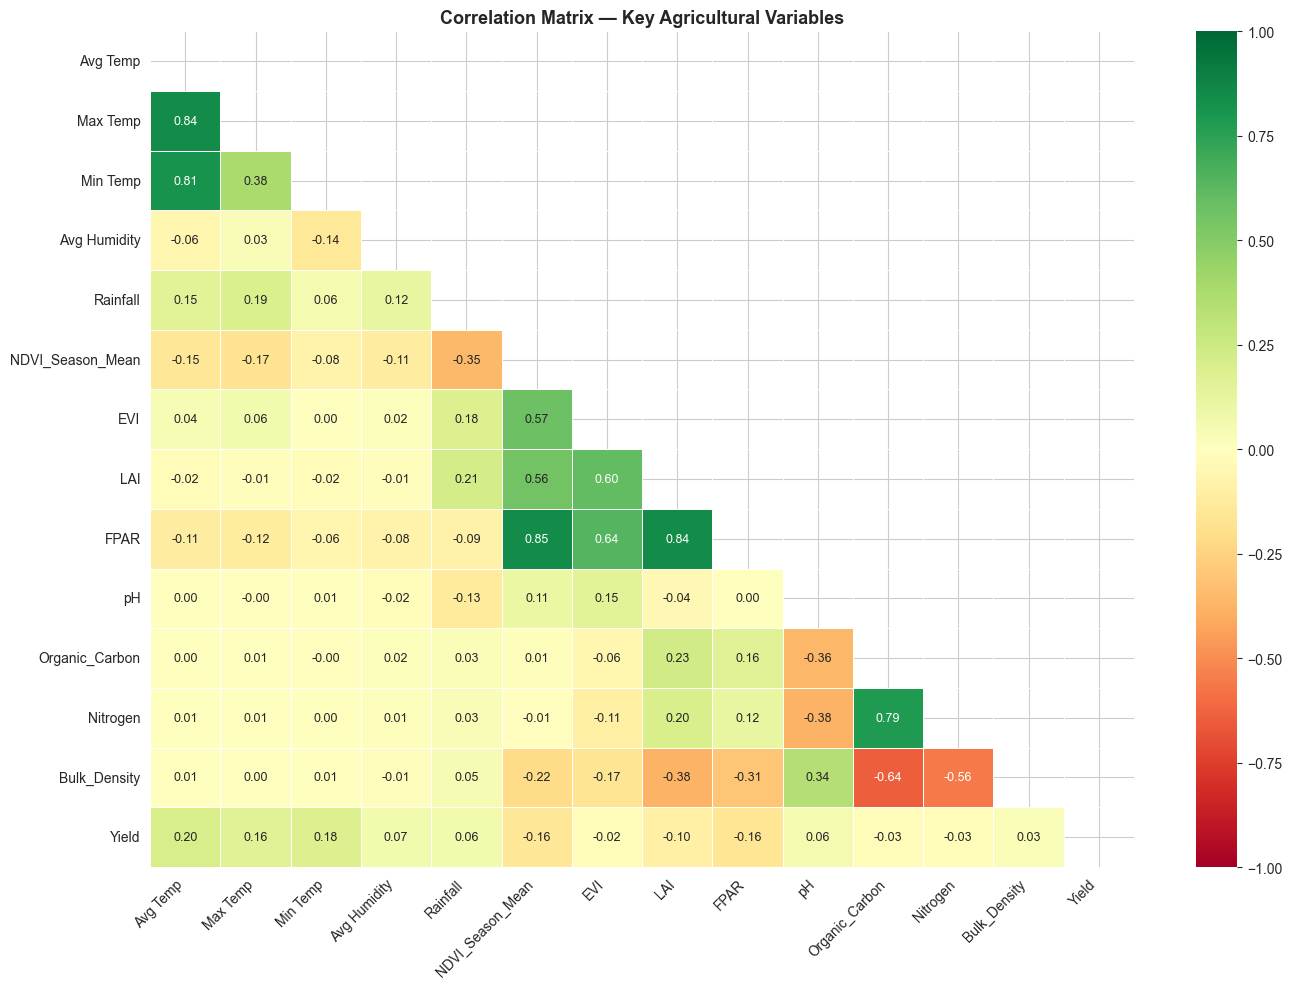


Top correlations with Yield:
Avg Temp            0.2050
Min Temp            0.1820
FPAR               -0.1640
Max Temp            0.1590
NDVI_Season_Mean   -0.1560
LAI                -0.0950
Avg Humidity        0.0690
Rainfall            0.0630
pH                  0.0550
Bulk_Density        0.0270
Nitrogen           -0.0270
Organic_Carbon     -0.0250
EVI                -0.0230


In [11]:
# ─── 7. CORRELATION MATRIX (Key Variables) ───────────────────────────────────
key_cols = ['Avg Temp','Max Temp','Min Temp','Avg Humidity','Rainfall',
            'NDVI_Season_Mean','EVI','LAI','FPAR',
            'pH','Organic_Carbon','Nitrogen','Bulk_Density','Yield']

corr_matrix = df[key_cols].corr().round(3)

plt.figure(figsize=(14, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, vmin=-1, vmax=1,
            linewidths=0.5, annot_kws={'size': 9})
plt.title('Correlation Matrix — Key Agricultural Variables', fontweight='bold', fontsize=13)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nTop correlations with Yield:')
yield_corr = corr_matrix['Yield'].drop('Yield').sort_values(key=abs, ascending=False)
print(yield_corr.to_string())

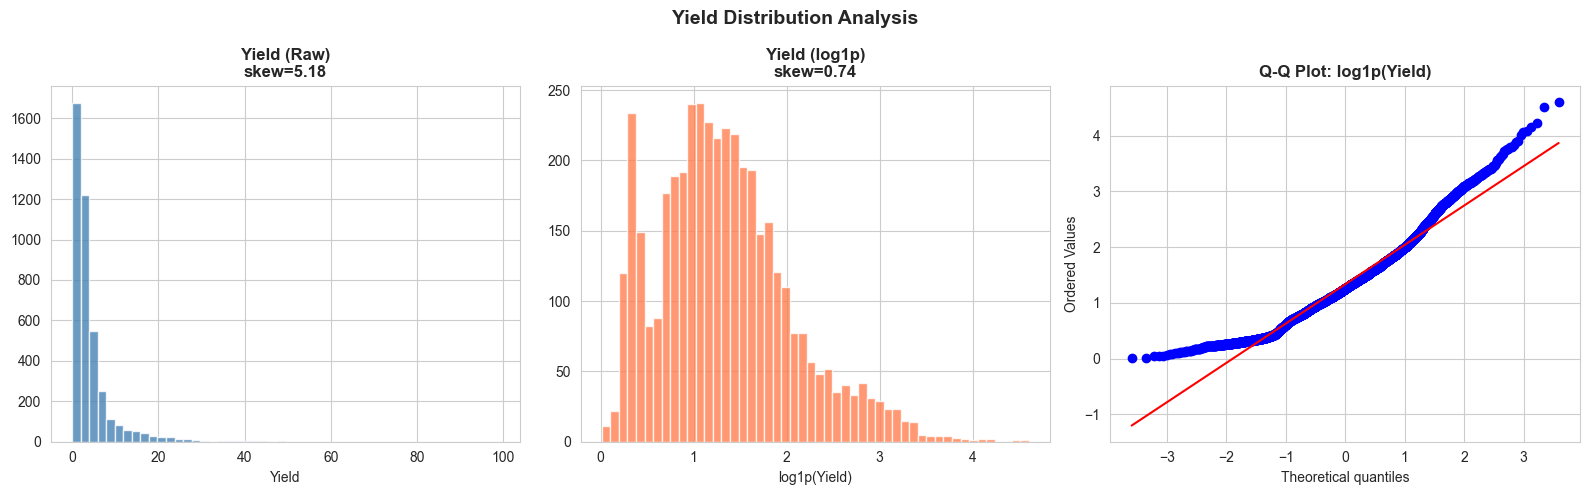

Log-transformed yield skewness: 0.7421 (much closer to 0)


In [12]:
# ─── 8. YIELD DISTRIBUTION & LOG TRANSFORM ───────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Raw
axes[0].hist(df['Yield'].dropna(), bins=50, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].set_title(f'Yield (Raw)\nskew={df["Yield"].skew():.2f}', fontweight='bold')
axes[0].set_xlabel('Yield')

# Log transform
log_yield = np.log1p(df['Yield'].dropna())
axes[1].hist(log_yield, bins=50, color='coral', edgecolor='white', alpha=0.8)
axes[1].set_title(f'Yield (log1p)\nskew={log_yield.skew():.2f}', fontweight='bold')
axes[1].set_xlabel('log1p(Yield)')

# QQ plot
stats.probplot(log_yield, dist='norm', plot=axes[2])
axes[2].set_title('Q-Q Plot: log1p(Yield)', fontweight='bold')

plt.suptitle('Yield Distribution Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('yield_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Log-transformed yield skewness: {log_yield.skew():.4f} (much closer to 0)')

In [13]:
# ─── 9. SUMMARY OF KEY FINDINGS ──────────────────────────────────────────────
high_skew_vars = skew_df[skew_df['Skew_Class'] == 'High Skew ⚠️'].index.tolist()
inf_vif_vars   = vif_df[vif_df['VIF'] == np.inf]['Feature'].tolist()
high_vif_vars  = vif_df[(vif_df['VIF'] > 10) & (vif_df['VIF'] != np.inf)]['Feature'].tolist()

print('=' * 65)
print('           KEY FINDINGS SUMMARY')
print('=' * 65)
print(f'\n📊 DATASET')
print(f'  Rows: {df.shape[0]:,}  |  Columns: {df.shape[1]}  |  Missing: 0')
print(f'  Numeric: {len(num_cols)}  |  Categorical: {df.select_dtypes(include="object").shape[1]}')

print(f'\n📐 SKEWNESS (|skew| ≥ 1 = highly skewed)')
print(f'  Count of highly skewed variables: {len(high_skew_vars)}')
print(f'  Variables: {high_skew_vars}')
print(f'  → Log transformation recommended for modeling')

print(f'\n🔗 MULTICOLLINEARITY (VIF)')
print(f'  Perfect multicollinearity (VIF=∞): {inf_vif_vars}')
print(f'  High multicollinearity (VIF>10)  : {high_vif_vars[:5]}...')
print(f'  → Drop or combine redundant features before regression')
print(f'    • Clay + Sand + Silt = 100% (perfect linear dependence)')
print(f'    • Avg Temp = (Max Temp + Min Temp) / 2')
print(f'    • sm_surface / sm_rootzone highly correlated')

print(f'\n📈 YIELD INSIGHTS')
print(f'  Yield skewness      : {df["Yield"].skew():.2f} (heavy right tail)')
print(f'  Strongest predictor : Avg Temp (r={df[["Avg Temp","Yield"]].corr().iloc[0,1]:.3f})')
print(f'  All normality tests : FAILED → use non-parametric methods or transform')

print(f'\n✅ RECOMMENDATIONS')
print('  1. Apply log1p transform to Yield, Production, Area before modeling')
print('  2. Drop Clay or Sand or Silt (sum-to-100 constraint)')
print('  3. Keep only one of: Avg Temp / Max Temp / Min Temp')
print('  4. Use Spearman correlation or tree-based models (non-normal data)')
print('  5. Consider PCA to reduce the 41 numeric features')

           KEY FINDINGS SUMMARY

📊 DATASET
  Rows: 4,178  |  Columns: 51  |  Missing: 0
  Numeric: 41  |  Categorical: 10

📐 SKEWNESS (|skew| ≥ 1 = highly skewed)
  Count of highly skewed variables: 12
  Variables: ['Area', 'Heat_Stress_Days', 'Is_Extreme_Heat', 'Moisture_Ratio', 'NDVI_Season_CV', 'Nitrogen', 'Production', 'Rootzone_Surface_Diff', 'Yield', 'is_extreme_Heat_Stress_Days', 'is_extreme_Wind_Max', 'sm_rootzone']
  → Log transformation recommended for modeling

🔗 MULTICOLLINEARITY (VIF)
  Perfect multicollinearity (VIF=∞): ['Avg Temp', 'Min Temp', 'Max Temp', 'Rootzone_Surface_Diff', 'sm_surface', 'sm_rootzone', 'Sand', 'Clay', 'Silt']
  High multicollinearity (VIF>10)  : ['Rainfall', 'Rain_Temp_Ratio', 'NDVI_Season_Max', 'NDVI_Season_Range', 'NDVI_Season_Min']...
  → Drop or combine redundant features before regression
    • Clay + Sand + Silt = 100% (perfect linear dependence)
    • Avg Temp = (Max Temp + Min Temp) / 2
    • sm_surface / sm_rootzone highly correlated

📈 YI